# Model selection: immunogenicity tools: Antibodies
This script aims to perform model selection on immunogenicity prediction tools. Previously different tools and settings have been tested. Comparision to anti-drug antibody (ADA) data using mainly spearman rank correlation, but also Mean Absolute Rank Error (MARE), to the tool scores has resulted in the tools and settings selected for testing in this script. Here the intention is to combine the tools to one predictive model, and perform ridge regression to investigate which tools have the most infulence on the best predicted response. Here ADA data will again be used as the correct/observed response varaible. In difference to previous testing the raw ADA score as well as the raw tool output score will be used in the model selection.\
\
The selected tools and settings for this secondary testing are\
1. netMHC1_EL_pep9:\
netMHCpan for MHC class 1, prediction type EL (elution ligand), peptide length 9, sliding window 5 and the only aviable pre prepare human allel panel with 27 alleles. These are the default settings for this tool.For this prediction 3 types of score are provided: the precentile_EL score, the immunogenicity score and the MHC pre processing score.\
2. netMHC1_pep14:\
This the same settings as scores above, expcet that the peptide length is 14. This are the best scoring settings for this tool\
3. netMHC_II_EL_pep12:\
netMHCpan for MHC class 2, prediciton type EL, peptide length 12, sliding window 5 and human 27 allele panel. For this tool there are two huaman allele panels, either 7 or 27. the human 27 allele panel scored marginally higher with all other combination of settings. Further, for this tool there are 2 different scores: the precentile_EL score and the immunogenicity score. THe MHC pre processing score is not availabe for these settings, only for peptide lengths 13 to 23. This tool and setting combination was the absolute highest scoring one in the initail testing\
4. netMHC_II_EL_pep15:\
This is the same settings as above (3.) but with peptide length 15. Here there are 3 scores: preceintile_EL, immunogenicity and MHC pre processing. This are the default settings for this tool.\
5. biophi_KabKabRelaxed:\
BioPhi OASis predicts how human a peptide is. The numbering scheme is Kabat, CDR definition Kabat and the human percent threshold is set to relaxed (>50%). This is the default setttings for this tool. This tool did not score very high on the spearman rank correlation in the initial testing, however that was calcualted on antibodies only and the main concern here is nanobodies. This tool had the best MARE scores for nanobodies and is therefore included here.\
6. biophi_KabKabStrict\
BioPhi OASis predicts how human a peptide is. The numbering scheme is Kabat, CDR definition Kabat and the human percent threshold is set to strict (>10%). This is the highest scoring settings for this tool.\
7. waltz\
This is a aggregation prediciton tool that has been included because it might improve the immunogenicity predicitons. Default settings are used.\



In [1]:
# load libaries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as sm

In [2]:
# tool outputs
netMHC1_EL_pep9 = pd.read_csv("tool_outputs/AB_netMHC_peplen9_18_03_2026.csv")
netMHC1_EL_pep14 = pd.read_csv("tool_outputs/AB_netMHC_peplen14_18_03_2026.csv")
netMHC_II_EL_pep12 = pd.read_csv("tool_outputs/AB_netMHC_II_peplen12_19_03_2026.csv")
netMHC_II_EL_pep15 = pd.read_csv("tool_outputs/AB_netMHC_II_peplen15_19_03_2026.csv")
biophi_KabKabRelaxed = pd.read_excel("tool_outputs/AB_NRKab_CDRKab_Relaxed_2026-02-25.xlsx")
biophi_KabKabStrict = pd.read_excel("tool_outputs/AB_NrKAb_CDRKab_Strict_2026-02-25.xlsx")
waltz = pd.read_csv("tool_outputs/AB_waltz.txt", sep="\t", header=None, names=["antibody", "waltz_score", "..."])

# load table with the antibody names
seqTable = pd.read_csv("tool_outputs/AB_seqTable_netMHC_II_peplen12.csv")

# load file containing the antibody name and their observed ADA percantage
ADA = pd.read_csv("../../../data/ADA_37AB.txt", sep="\t", header=None, names=["antibody", "ADA_percentage"])

In [3]:
# There are some nanobodies left in the dataset from the inital testing, which are removed here
biophi_KabKabRelaxed = biophi_KabKabRelaxed[((biophi_KabKabRelaxed.Antibody != "Caplacizumab") & 
                                             (biophi_KabKabRelaxed.Antibody != "Vobarilizumab_HC2") & 
                                             (biophi_KabKabRelaxed.Antibody != "Vobarilizumab_HC1"))]

biophi_KabKabStrict = biophi_KabKabStrict[((biophi_KabKabStrict.Antibody != "Caplacizumab") & 
                                           (biophi_KabKabStrict.Antibody != "Vobarilizumab_HC2") & 
                                           (biophi_KabKabStrict.Antibody != "Vobarilizumab_HC1"))]

In [4]:
# Sanity checks

# Check nr of antibodies
if netMHC1_EL_pep14['seq #'].nunique()!=37:
        print( "netMHC1_EL_pep14 does not have 37 antibodies")
if netMHC1_EL_pep9['seq #'].nunique()!=37:
        print( "netMHC1_EL_pep9 does not have 37 antibodies")
if netMHC_II_EL_pep12['seq #'].nunique()!=37:
        print( "netMHC_II_EL_pep12 does not have 37 antibodies")   
if netMHC_II_EL_pep15['seq #'].nunique()!=37:
        print( "netMHC_II_EL_pep15 does not have 37 antibodies")
if biophi_KabKabRelaxed['Antibody'].nunique()!=37:
        print( "biophi_KabKabRelaxed does not have 37 antibodies")
if biophi_KabKabStrict['Antibody'].nunique()!=37:
        print( "biophi_KabKabStrict does not have 37 antibodies")
if waltz['antibody'].nunique()!=37:
        print( "waltz does not have 37 antibodies")


netMHC tools remove the antibody name for analysis, below the antibody name is mapped back

In [5]:
# the netMHC tools do not have the antibody name in the output, only a sequence number
# Here the seq # will be mapped back to the original antibody name using the seqTable
netMHC1_EL_pep9 = netMHC1_EL_pep9.merge(seqTable[['seq #', 'sequence name']], how='left')
netMHC1_EL_pep14 = netMHC1_EL_pep14.merge(seqTable[['seq #', 'sequence name']], how='left')
netMHC_II_EL_pep12 = netMHC_II_EL_pep12.merge(seqTable[['seq #', 'sequence name']], how='left')
netMHC_II_EL_pep15 = netMHC_II_EL_pep15.merge(seqTable[['seq #', 'sequence name']], how='left')


# Compute scores


netMHCpan tools give one score for each peptide - HLA allele combination
Therefore, for each antibody a immunogenicity score will be calculated. The definition of what score is considerd immunogenetic differs for the different tools \
for each netMHC score of interest: precentile score, immunogenicity socre and pre processing score

For the two dataframes netMHC_II_EL_pep15 and netMHC_II_EL_pep12, there are some score values missing (looks like this '-'). 
Below these values have been removed. I have tried to remake the predicitons but I get the same results. I does not seem to be for one speciifc, antibody, HLA allele or something else. The number of missing values are exacly the same when remaking the prediction, this applys to both data frames. Therefore, I belive it is something that for some reason cant be predicted and have simply removed these values. 

In [6]:
# netMHC1_EL_pep9 percentile score

# Immunogenentic is defened as scored <= 1%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 1. 
netMHC1_pep9_percentile = (
    netMHC1_EL_pep9.assign(immunogenic=netMHC1_EL_pep9['netmhcpan_el percentile'] <= 1) # flags rows where percentile is below 1
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep9_percentile')
    )


In [7]:
# netMHC1_EL_pep9 Immunogenicity score 

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
netMHC1_pep9_immunogenicity_score = (
    netMHC1_EL_pep9.assign(immunogenic=netMHC1_EL_pep9['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep9_immunogenicity_score')
    )


In [8]:
# netMHC1_EL_pep9 Preprocessing score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMCH1_pep9_preProcess = netMHC1_EL_pep9.groupby('sequence name')['processing total score'].mean().reset_index().rename(columns={'processing total score': 'netMHC1_pep9_preProcess'})

In [9]:
# netMHC1_EL_pep14

# Percentile score

# Immunogenentic is defened as scored <= 1%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 1. 
netMHC1_pep14_percentile = (
    netMHC1_EL_pep14.assign(immunogenic=netMHC1_EL_pep14['netmhcpan_el percentile'] <= 1) # flags rows where percentile is below 1
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep14_percentile')
    )

# Immunogenicity score

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
netMHC1_pep14_immunogenicity_score = (
    netMHC1_EL_pep14.assign(immunogenic=netMHC1_EL_pep14['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep14_immunogenicity_score')
    )

# Pre-proocessing score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMCH1_pep14_preProcess = netMHC1_EL_pep14.groupby('sequence name')['processing total score'].mean().reset_index().rename(columns={'processing total score': 'netMHC1_pep14_preProcess'})


In [10]:
# netMHC_II_EL_pep12

# Percentile score

# Immunogenentic is defened as scored <= 10%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 10. 
netMHC_II_pep12_percentile = (
    netMHC_II_EL_pep12.assign(immunogenic=netMHC_II_EL_pep12['netmhciipan_el percentile'] <= 10) # flags rows where percentile is below 10
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_II_pep12_percentile')
    )

# Immunogenicity score

# remove the rows with the immunogenicity score of '-' before calculating the mean
netMHC_II_EL_pep12 = netMHC_II_EL_pep12[netMHC_II_EL_pep12['immunogenicity score'] != '-']
# make the column with the immunogenicity score into a numeric column
netMHC_II_EL_pep12['immunogenicity score'] = pd.to_numeric(netMHC_II_EL_pep12['immunogenicity score'])

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody.
netMHC_II_pep12_immunogenicity_score = netMHC_II_EL_pep12.groupby('sequence name')['immunogenicity score'].mean().reset_index().rename(columns={'immunogenicity score':'netMHC_II_pep12_immunogenicity_score'})


# Does not have pre processing score. Due to tool not being able to predict pre processing on peptides shorter than 13 amino acids


In [11]:
# netMHC_II_EL_pep15

# Percentile score

# Immunogenentic is defened as scored <= 10%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 10. 
netMHC_II_pep15_percentile = (
    netMHC_II_EL_pep15.assign(immunogenic=netMHC_II_EL_pep15['netmhciipan_el percentile'] <= 10) # flags rows where percentile is below 10
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_II_pep15_percentile')
    )

# Immunogenicity score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_pep15_immunogenicity_score = netMHC_II_EL_pep15.groupby('sequence name')['immunogenicity score'].mean().reset_index().rename(columns={'immunogenicity score':'netMHC_II_pep15_immunogenicity_score'})

# Pre-proocessing score
# MHC class 2 has 2 preprocessing scores of interest: mhcii-np cleavage probability score and mhcii-np cleavage probability percentile rank

# mhcii-np cleavage probability

# remove the rows with the cleavage probability score of '-' before calculating the mean
netMHC_II_EL_pep15 = netMHC_II_EL_pep15[netMHC_II_EL_pep15['mhcii-np cleavage probability score'] != '-']
# make the column with the cleavage probability score into a numeric column
netMHC_II_EL_pep15['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II_EL_pep15['mhcii-np cleavage probability score'])
# Compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_pep15_preProcess_cleavProb = netMHC_II_EL_pep15.groupby('sequence name')['mhcii-np cleavage probability score'].mean().reset_index().rename(columns={'mhcii-np cleavage probability score': 'netMHC_II_pep15_preProcess_cleavProb'})

# mhcii-np cleavage probability percentile rank

# remove the rows with the cleavage probability percentile rank of '-' before calculating the mean
netMHC_II_EL_pep15 = netMHC_II_EL_pep15[netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'] != '-']
# make the column with the cleavage probability percentile rank into a numeric column
netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'] = pd.to_numeric(netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'])
# compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_pep15_preProcess_cleavProbPercentile = netMHC_II_EL_pep15.groupby('sequence name')['mhcii-np cleavage probability percentile rank'].mean().reset_index().rename(columns={'mhcii-np cleavage probability percentile rank': 'netMHC_II_pep15_preProcess_cleavProbPercentile'})

waltz provides a output that is the positions of amino acid sequences that are considerd aggregation prone. To calculate a quatiable score from that I just take the total ammount of amino acids that are considerd to me aggregation prone. I take total amount of amino acids instead of number of regions because a longer region will be more aggreagtion prone than a shorter region.

In [12]:
# rename the column '...' to nr_aggs
waltz = waltz.rename(columns={'...': 'nr_aggs'})

# compute the total number of amio acids that are considerd immunogenetic
def sum_ranges(s):
    if pd.isna(s):
        return 0
    total = 0
    for part in s.split(';'):
        start, end = part.strip().split('-')
        total += int(end) - int(start) + 1 # beacuse the values are inclusive
    return total

waltz['nr_aggs'] = waltz['waltz_score'].apply(sum_ranges)

In [13]:
waltz

,antibody,waltz_score,nr_aggs
0,BEZLOTOXUMAB,66-71; 152-158; 165-170; 203-219,36
1,ECULIZUMAB,28-36; 91-102; 154-158; 167-175; 204-210,42
2,INFLIXIMAB,25-37; 93-98; 152-157,25
3,DUPILUMAB,91-95; 162-168; 175-181; 213-219,26
4,IBALIZUMAB,47-55; 91-95; 107-118; 160-166; 173-181; 211-226,58
5,OCRELIZUMAB,91-118; 203-215,41
6,USTEKINUMAB,102-115; 151-156; 164-169; 201-218,44
7,RITUXIMAB,44-53; 91-112; 152-157; 165-175; 203-214,61
8,BRODALUMAB,47-55; 91-95; 99-112; 148-154; 199-208,45
9,BASILIXIMAB,44-53; 91-97; 99-113; 148-154; 199-204,45


In [14]:
# join all the new dfs with the ADA dataframe. Based on the 'sequence name' in the new dfs and the 'antibody' column in the ADA df
all_predictors_andADA = ADA
all_predictors_andADA = all_predictors_andADA.merge(netMHC1_pep9_percentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC1_pep9_immunogenicity_score, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMCH1_pep9_preProcess, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC1_pep14_percentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC1_pep14_immunogenicity_score, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMCH1_pep14_preProcess, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep12_percentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep12_immunogenicity_score, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep15_percentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep15_immunogenicity_score, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep15_preProcess_cleavProb, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
all_predictors_andADA = all_predictors_andADA.merge(netMHC_II_pep15_preProcess_cleavProbPercentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])

# Add the OASis Identity score from biophi_KabKabRelaxed to ADA df
all_predictors_andADA = all_predictors_andADA.merge(biophi_KabKabRelaxed[['Antibody', 'OASis Identity']], left_on='antibody', right_on='Antibody', how='left').drop(columns=['Antibody']).rename(columns={'OASis Identity': 'biophi_KabKabRelaxed_score'})
# Add biophi_KabKabStrict
all_predictors_andADA = all_predictors_andADA.merge(biophi_KabKabStrict[['Antibody', 'OASis Identity']], left_on='antibody', right_on='Antibody', how='left').drop(columns=['Antibody']).rename(columns={'OASis Identity': 'biophi_KabKabStrict_score'})

# Add the nr_aggs score from waltz to the ADA df
all_predictors_andADA = all_predictors_andADA.merge(waltz[['antibody', 'nr_aggs']], left_on='antibody', right_on='antibody', how='left').rename(columns={'nr_aggs': 'waltz_nr_aggs'})

In [15]:
# Make all white space and '-' in the column names to '_'
all_predictors_andADA.columns = (
    all_predictors_andADA.columns
    .str.replace(r'[\s\-]+', '_', regex=True)
)

In [16]:
all_predictors_andADA
# export the ADA df to a csv file
all_predictors_andADA.to_csv("ADA_combined_features.csv", index=False)

# Scatterplot ADA against all 15 predictors

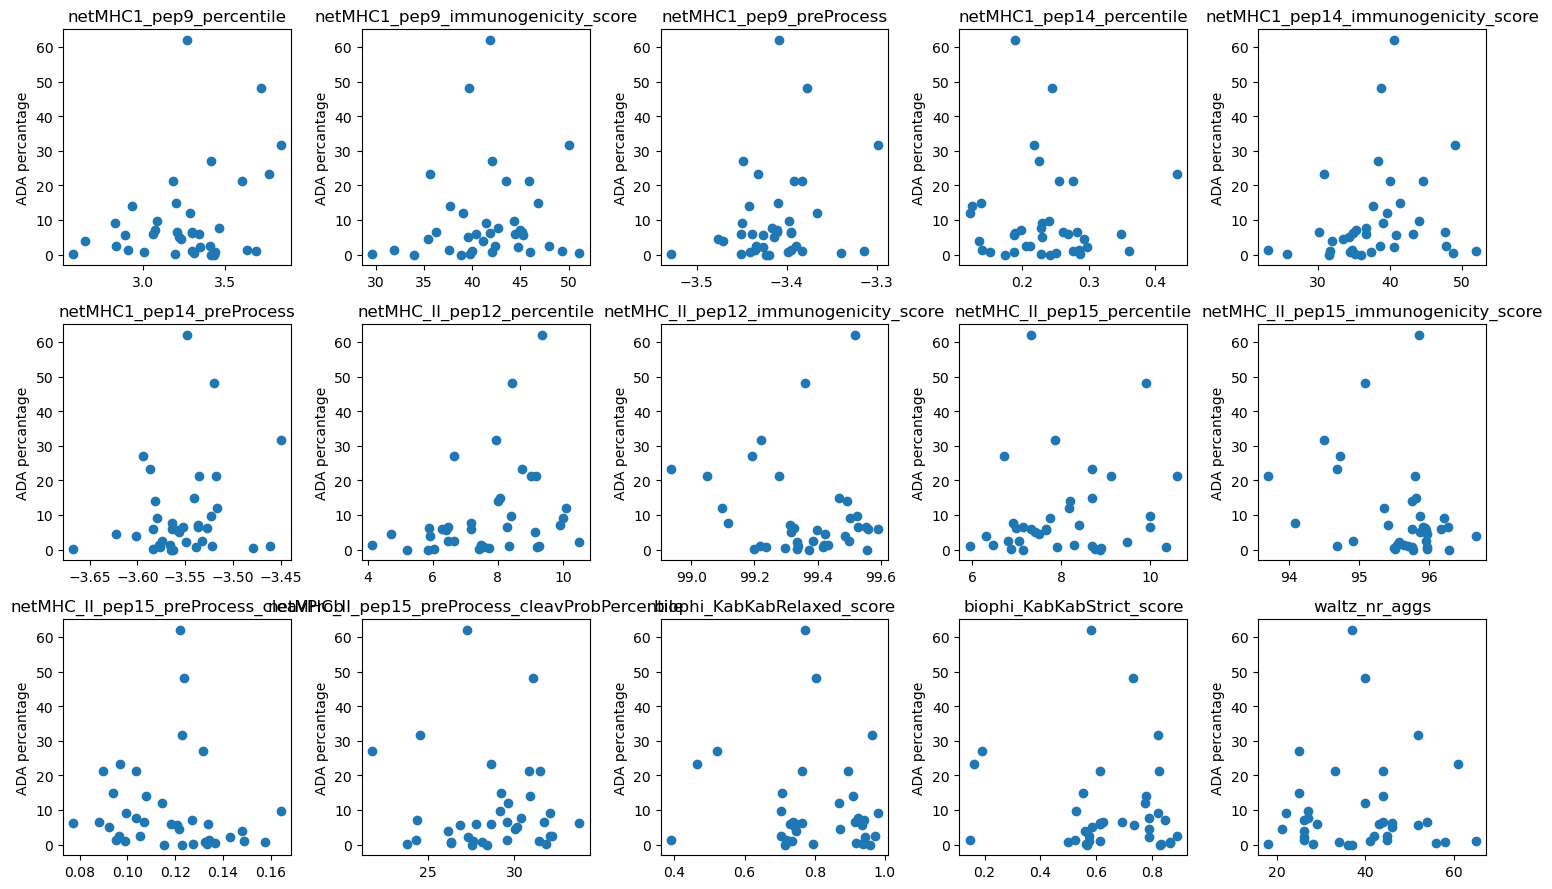

In [17]:
# for loop for all columns, make a scatter plot for each predictor against ADA

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(2, 17):
    ax = axes[i - 2]
    
    y = all_predictors_andADA['ADA_percentage']
    x = all_predictors_andADA.iloc[:, i]
    
    ax.scatter(x, y)
    ax.set_title(all_predictors_andADA.columns[i])
    ax.set_ylabel('ADA percantage')

plt.tight_layout()
plt.show()

# Correlation of potential predictors

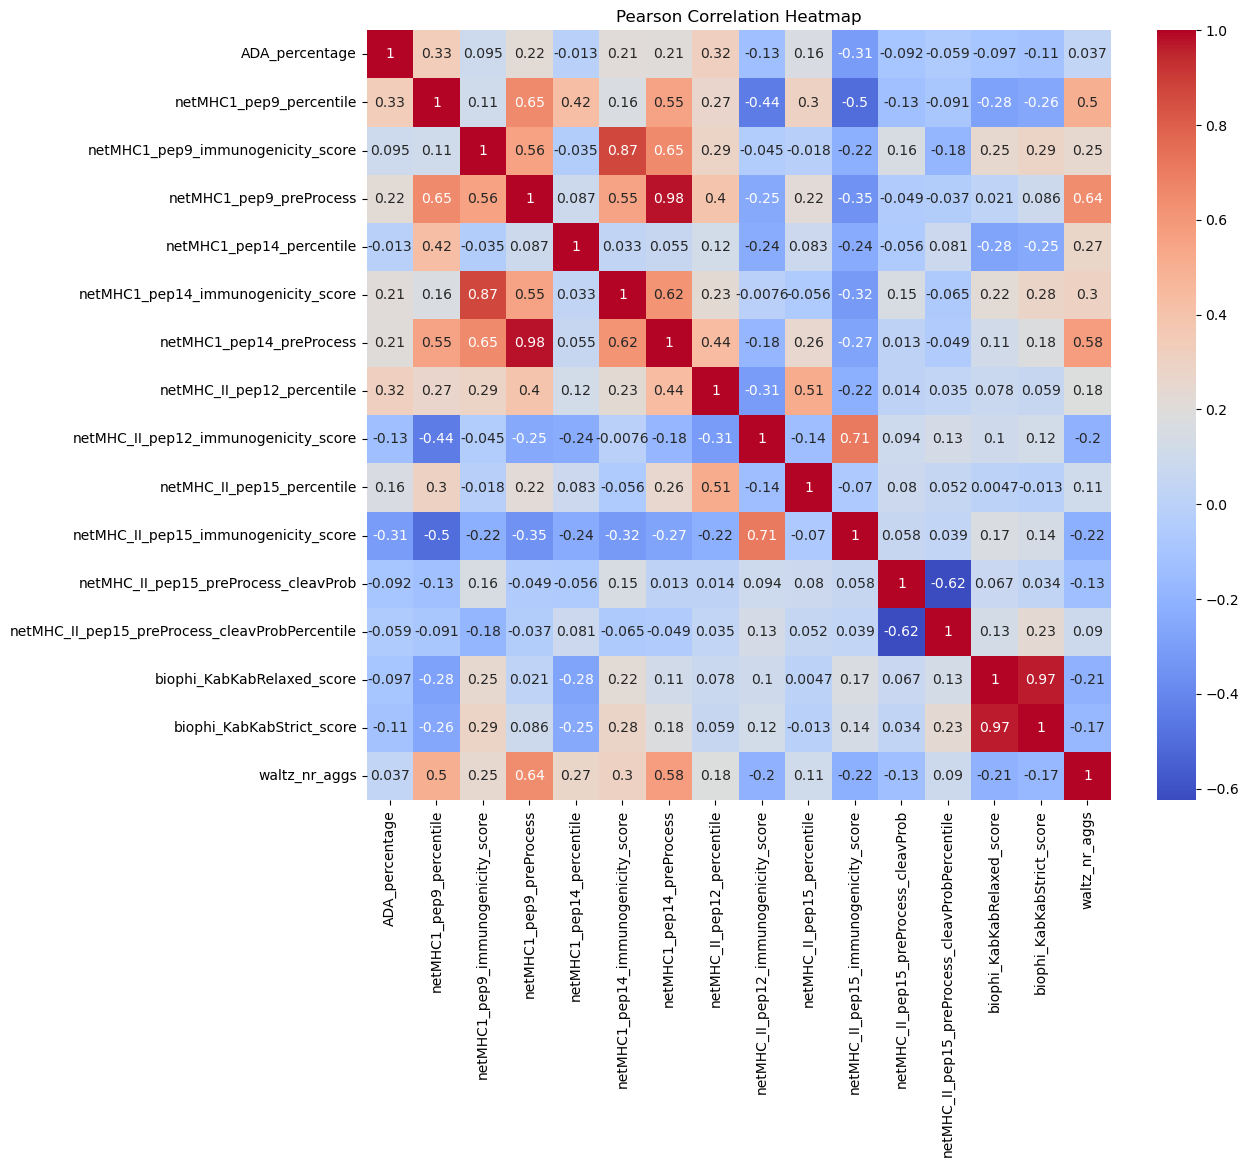

In [18]:
# First create a df without the antibody name and ADA percantage
ADA_corrtest = all_predictors_andADA.drop(columns=['antibody'])
pearson_corr = ADA_corrtest.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()

From the heatmap above we can see a few interesting things.
Firstly, the highest correlation with ADA percantge is netMHC_II_pep15_percentile. Which also was the higest scoring one in the initial testing. So, this is a confirmation of those results. The spearman rank correlation for this combination was ~0.4, here the score is ~0.39, so that also a conformation of the initial results.
Further, there are a few high correlations between tools and settings.
netMCH1 for peptide lengths 9 and 14 correlates very well for the immmunogenicity score and the pre processing score.
Another kind of strong correlation is between netMCH_II for peptide lenghts 12 and 15, which have a high correlation between them for both the percentile score and the immunogenicity score. 

In [19]:
# print the correlation of the ADA percentage column
pearson_corr['ADA_percentage'].sort_values(ascending=False)

ADA_percentage                                    1.000000
netMHC1_pep9_percentile                           0.334092
netMHC_II_pep12_percentile                        0.317668
netMHC1_pep9_preProcess                           0.224732
netMHC1_pep14_immunogenicity_score                0.206894
netMHC1_pep14_preProcess                          0.205337
netMHC_II_pep15_percentile                        0.157330
netMHC1_pep9_immunogenicity_score                 0.095171
waltz_nr_aggs                                     0.037079
netMHC1_pep14_percentile                         -0.012749
netMHC_II_pep15_preProcess_cleavProbPercentile   -0.059006
netMHC_II_pep15_preProcess_cleavProb             -0.091702
biophi_KabKabRelaxed_score                       -0.096572
biophi_KabKabStrict_score                        -0.113934
netMHC_II_pep12_immunogenicity_score             -0.134675
netMHC_II_pep15_immunogenicity_score             -0.307954
Name: ADA_percentage, dtype: float64

# Lasso regression

In [20]:
# Create feature variables
X = all_predictors_andADA.drop(columns=['antibody', 'ADA_percentage']) # all except the response variable and the antibody names
y = all_predictors_andADA['ADA_percentage'] # the response varibale

model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5,max_iter=10000)  # cross-validation
)

model.fit(X, y)

# coefficients
coef = model.named_steps['lassocv'].coef_

selected_features = X.columns[coef != 0]


In [21]:
# print the features that Lasso "decided" are the best once to use for the prediction
selected_features

Index(['netMHC1_pep9_percentile', 'netMHC_II_pep12_percentile',
       'netMHC_II_pep15_immunogenicity_score'],
      dtype='object')

# Manual multiple regression


In [22]:
# print all column names, to get an overview of what potetnial predictors can be used 
X.iloc[1]

netMHC1_pep9_percentile                            3.414883
netMHC1_pep9_immunogenicity_score                 33.944954
netMHC1_pep9_preProcess                           -3.422947
netMHC1_pep14_percentile                           0.173883
netMHC1_pep14_immunogenicity_score                31.455399
netMHC1_pep14_preProcess                          -3.562589
netMHC_II_pep12_percentile                         5.857020
netMHC_II_pep12_immunogenicity_score              99.372712
netMHC_II_pep15_percentile                         8.871662
netMHC_II_pep15_immunogenicity_score              95.770937
netMHC_II_pep15_preProcess_cleavProb               0.115206
netMHC_II_pep15_preProcess_cleavProbPercentile    27.552143
biophi_KabKabRelaxed_score                         0.714286
biophi_KabKabStrict_score                          0.566667
waltz_nr_aggs                                     37.000000
Name: 1, dtype: float64

In [24]:

# model 1
# The two features considred best my Lasso
model1 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep12_percentile + netMHC_II_pep15_immunogenicity_score', 
                data=all_predictors_andADA).fit()

# model 2
# The two scores from netMHC II, peptide length 12
model2 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep12_percentile + netMHC_II_pep12_immunogenicity_score', 
                data=all_predictors_andADA).fit()

# model 3
# The four scores from netMCH II, peptide length 15
model3 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC_II_pep15_percentile + netMHC_II_pep15_immunogenicity_score + netMHC_II_pep15_preProcess_cleavProb + ' \
'netMHC_II_pep15_preProcess_cleavProbPercentile',
                data=all_predictors_andADA).fit()

# model 4
# The three features from netMCH I, peptide length 9
model4 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep9_percentile + netMHC1_pep9_immunogenicity_score + netMHC1_pep9_preProcess' ,
                data=all_predictors_andADA).fit()

# model 5
# The three features from netMCH I, peptide length 14
model5 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep14_percentile + netMHC1_pep14_immunogenicity_score + netMHC1_pep14_preProcess',
                data=all_predictors_andADA).fit()

In [25]:
# Compute and print model fit calculations
print('AIC, R^2, adjusted R^2')
print("Model1:", model1.aic, model1.rsquared, model1.rsquared_adj)
print("Model2:", model2.aic, model2.rsquared, model2.rsquared_adj)
print("Model3:", model3.aic, model3.rsquared, model3.rsquared_adj)
print("Model4:", model4.aic, model4.rsquared, model4.rsquared_adj)
print("Model5:", model5.aic, model5.rsquared, model5.rsquared_adj)

AIC, R^2, adjusted R^2
Model1: 297.0566754253589 0.16032580664692297 0.11093320703791842
Model2: 299.52823203659597 0.10232078859671134 0.04951612910240022
Model3: 301.9102422853267 0.1407298843730398 0.033321119919669795
Model4: 300.9296329014215 0.11672691363734122 0.03642936033164501
Model5: 303.5047526457395 0.05306329384022579 -0.03302186126520823


BIC and adjusted R^2 penalise more for more predictors. Which we can see here, but also not really what im after. AIC also penalises for more parameters, so im mostly looking at R^2.\
Comparing which settings are best for netMHC II, we look at model 2 and model 3. Where model 3 is better (look at R^2). This is with peptide length 15. \
Looking which settings are best for netMHC I, we look at model 4 and model 5. Here model 4 is clearly better. This is with peptide length 9.\
However the combination with netMHC_II_pep12_percentile + netMHC_II_pep15_immunogenicity_score' is still best performing.\
It is unpracticala that its the same tool but with two different settings, so I will first look at immunogenicity score and percetnile score with one settings to investigate which settings is better.

In [26]:
# model 1
# The two features considred best my Lasso
model1 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep12_percentile + netMHC_II_pep15_immunogenicity_score', 
                data=all_predictors_andADA).fit()

# model 6
# # Immunogenicity score and percentile score for netMHC II peptide length 15
model6 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep15_percentile + netMHC_II_pep15_immunogenicity_score', 
                data=all_predictors_andADA).fit()


# Print comparative scores
print('AIC, R^2, adjusted R^2')
print("Model1:", model1.aic, model1.rsquared, model1.rsquared_adj)
print("Model6:", model6.aic, model6.rsquared, model6.rsquared_adj)

AIC, R^2, adjusted R^2
Model1: 297.0566754253589 0.16032580664692297 0.11093320703791842
Model6: 299.070504176859 0.11335758995883882 0.061202154074064596


Between model 6 and model 7, model 7 score better on the R^2. This is also default settings, so I will continue with that. 


For the netMHC (class 1) tools the settings with pepetide length 9 scores better than the one with peptide length 14, when looking at R^2 which is the only score that does not penalize for more preditors. Peptide length 9 is also the deafult settings. Below I will investigate if removing some of the predicitors improves the score. 

In [27]:
# model 4
# The three features from netMCH I, peptide length 9
model4 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep9_percentile + netMHC1_pep9_immunogenicity_score + netMHC1_pep9_preProcess' ,
                data=all_predictors_andADA).fit()

# model 7
# Only the percentile fetaure for netMHC I, peptide length 9
model7 = sm.ols(formula= 'ADA_percentage ~ netMHC1_pep9_percentile',
                data=all_predictors_andADA).fit()

# model 8
# Only the immunogenicity fetaure for netMHC I, peptide length 9
model8 = sm.ols(formula= 'ADA_percentage ~ netMHC1_pep9_immunogenicity_score',
                data=all_predictors_andADA).fit()                

# model 9
# The two features percentile and immunogenicity for nethMHC I, pepetide length 9
model9 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep9_percentile + netMHC1_pep9_immunogenicity_score' ,
                data=all_predictors_andADA).fit()


# Print comparative scores
print('AIC, R^2, adjusted R^2')
print("Model4:", model4.aic, model4.rsquared, model4.rsquared_adj)
print("Model7:", model7.aic, model7.rsquared, model7.rsquared_adj)
print("Model8:", model8.aic, model8.rsquared, model8.rsquared_adj)
print("Model9:", model9.aic, model9.rsquared, model9.rsquared_adj)

AIC, R^2, adjusted R^2
Model4: 300.9296329014215 0.11672691363734122 0.03642936033164501
Model7: 297.143047436438 0.11161750818903471 0.08623515128015002
Model8: 301.1854499712694 0.009057503576873627 -0.019255139178072644
Model9: 298.9917700333269 0.11524231450945832 0.06319774477472051


From the R^2 results from above, model 8 is not good at all (R^2 = 0.011), so only using the immunogenicity score is bad. And the best score is actualy to keep all three features. So, I will do that.\
\


In [28]:
# from the best scoring of the netMHC tools, add them together once and also check with biophi


# model 10
# best of netMHC and netMHC II in combination
model10 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep9_percentile + netMHC1_pep9_immunogenicity_score + netMHC1_pep9_preProcess +' \
'netMHC_II_pep15_percentile + netMHC_II_pep15_immunogenicity_score',
                data=all_predictors_andADA).fit()


# model 11
# Best of netMHC and netMHC II + waltz
model11 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep9_percentile + netMHC1_pep9_immunogenicity_score + netMHC1_pep9_preProcess +' \
'netMHC_II_pep15_percentile + netMHC_II_pep15_immunogenicity_score +'\
'waltz_nr_aggs',
                data=all_predictors_andADA).fit()


# model 12
# Best of netMHC and netMHC II + biophi Relaxed
model12 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep9_percentile + netMHC1_pep9_immunogenicity_score + netMHC1_pep9_preProcess +' \
'netMHC_II_pep15_percentile + netMHC_II_pep15_immunogenicity_score +' \
'biophi_KabKabRelaxed_score',
                data=all_predictors_andADA).fit()


# model 13
# Best of netMHC and netMHC II + biophi Strict
model13 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep9_percentile + netMHC1_pep9_immunogenicity_score + netMHC1_pep9_preProcess +' \
'netMHC_II_pep15_percentile + netMHC_II_pep15_immunogenicity_score +' \
'biophi_KabKabStrict_score',
                data=all_predictors_andADA).fit()

# model 14
# Best of netMHC and netMHC II + waltz + biophi
model14 = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep9_percentile + netMHC1_pep9_immunogenicity_score + netMHC1_pep9_preProcess +' \
'netMHC_II_pep15_percentile + netMHC_II_pep15_immunogenicity_score +'\
'waltz_nr_aggs +'\
'biophi_KabKabRelaxed_score',
                data=all_predictors_andADA).fit()

# Print comparative scores
print('AIC, R^2, adjusted R^2')
print("Model10:", model10.aic, model10.rsquared, model10.rsquared_adj)
print("Model11:", model11.aic, model11.rsquared, model11.rsquared_adj)
print("Model12:", model12.aic, model12.rsquared, model12.rsquared_adj)
print("Model13:", model13.aic, model13.rsquared, model13.rsquared_adj)
print("Model14:", model14.aic, model14.rsquared, model14.rsquared_adj)


AIC, R^2, adjusted R^2
Model10: 303.7043621124895 0.14549786837457013 0.007674943918855592
Model11: 304.62358493958976 0.17009701926442933 0.004116423117315193
Model12: 305.6981782878374 0.1456406697206586 -0.02523119633520965
Model13: 305.63397207748346 0.14712195640233927 -0.023453652317192875
Model14: 306.5081274293109 0.1726826729868014 -0.027014612843970776


The last model, model 14, which includes the most predictors acctually scores the best of all models, when looking at R^2 only. Better than the one from Lasso. The R^2 for model14 is 0.177, this means that the model explains ~18% of the variance in the ADA (observed variable)

In [29]:
# model 15
# Immunogenicity score and percentile score for netMHC II peptide length 12
model15 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep12_immunogenicity_score', 
                data=all_predictors_andADA).fit()

# model 16
# Best of netMHC and netMHC II + waltz + biophi
model16 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep15_percentile',
                data=all_predictors_andADA).fit()

# model 17
# Best of netMHC and netMHC II + waltz + biophi
model17 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep15_immunogenicity_score',
                data=all_predictors_andADA).fit()

# model 18
# Immunogenicity score and percentile score for netMHC II peptide length 12
model18 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep12_percentile', 
                data=all_predictors_andADA).fit()


# Print comparative scores
print('AIC, R^2, adjusted R^2')
print("Model15:", model15.aic, model15.rsquared, model15.rsquared_adj)
print("Model16:", model16.aic, model16.rsquared, model16.rsquared_adj)
print("Model17:", model17.aic, model17.rsquared, model17.rsquared_adj)
print("Model18:", model18.aic, model18.rsquared, model18.rsquared_adj)

AIC, R^2, adjusted R^2
Model15: 300.8448595506053 0.018137419341235916 -0.00991579724901448
Model16: 300.5947223779857 0.024752879108109194 -0.0031113243459446327
Model17: 297.8354770165389 0.09483549808827063 0.068973655176507
Model18: 297.5862118311147 0.10091300326930053 0.0752248033627092


In [30]:
# Put all model comparative scores into a dataframe
rows = []

for i in range(1,19):
    model_name = f"model{i}"
    model = globals()[model_name]

    # Extract the predictors for each model and make it into a string
    predictors = [x for x in model.model.exog_names if x != 'Intercept']
    predictor_str = ", ".join(predictors)

    # Create row for model
    rows.append({
        'Model name': model_name,
        'AIC': model.aic,
        'R^2': model.rsquared,
        'Adjusted R^2': model.rsquared_adj,
        'Number of predictors': len(model.params) - 1,
        'Predictors': predictor_str
    })

comp_models = pd.DataFrame(rows)

comp_models = comp_models.sort_values('AIC')

comp_models.to_excel("Multiple_regression_model_comparison.xlsx")



# Visualization of results
Since its a regression with multiple predictors I can't plot a regression line with the observed data as scatter. Because multiple predictors makes it to higher dimensions than 2.\
I can use the model to predict new values and plot the observed vs the predicted values. 

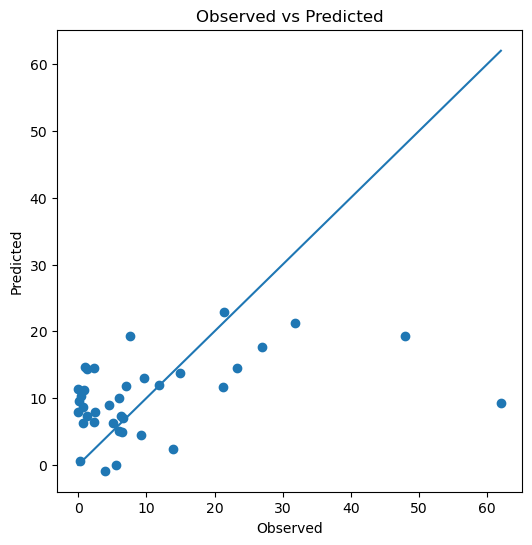

In [31]:
# Predict values based on the model 14 (best model when only looking at R^2)
all_predictors_andADA['predicted_ADA'] = model14.predict(all_predictors_andADA)

plt.figure(figsize=(6,6))
plt.scatter(all_predictors_andADA['ADA_percentage'], all_predictors_andADA['predicted_ADA'])

# ideal line (perfect fit)
plt.plot([all_predictors_andADA['ADA_percentage'].min(), all_predictors_andADA['ADA_percentage'].max()],
         [all_predictors_andADA['ADA_percentage'].min(), all_predictors_andADA['ADA_percentage'].max()])

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted")
plt.show()

So this plots shows how the obserev (ADA percantage) values and the predicted values (by model 14) relate to one antoher. If the prediction was perfect all dots would be along the blue line. \
\
In this plot there are two observed values that are really high, and in the plot one can see that they are not predicted to as high as they should have been. For example one dot is at ~60 as observed and predicted as ~10. These two dots are the anitbodies ALEMTUZUMAB and BOCOCIZUMAB which have very high ADA. To see how good the model is without these two outliers I will below remove them and make a regression model without them. 

In [32]:
# Make a copy of the all_predictors_andADA data frame but remove the two rows for ALEMTUZUMAB and BOCOCIZUMAB
#almost_all_predictors_andADA = all_predictors_andADA.copy
almost_all_predictors_andADA = all_predictors_andADA[~all_predictors_andADA['antibody'].isin(['ALEMTUZUMAB', 'BOCOCIZUMAB'])].copy()

In [33]:
# model special
# Best of netMHC and netMHC II + waltz + biophi
model_35AB = sm.ols(formula= 'ADA_percentage ~ ' \
'netMHC1_pep9_percentile + netMHC1_pep9_immunogenicity_score + netMHC1_pep9_preProcess +' \
'netMHC_II_pep15_percentile + netMHC_II_pep15_immunogenicity_score +'\
'waltz_nr_aggs +'\
'biophi_KabKabRelaxed_score',
                data=almost_all_predictors_andADA).fit()

# Print comparative scores
print('AIC, R^2, adjusted R^2')
print("Model14:", model14.aic, model14.rsquared, model14.rsquared_adj) # comare to same model where ALEMTUZUMAB and BOCOCIZUMAB are included
print("Model_35AB:", model_35AB.aic, model_35AB.rsquared, model_35AB.rsquared_adj)

AIC, R^2, adjusted R^2
Model14: 306.5081274293109 0.1726826729868014 -0.027014612843970776
Model_35AB: 249.40239299155442 0.3178129956885859 0.14094969827451553


Here the R^2 is 0.33 for model 15, where ALEMTUZUMAB and BOCOCIZUMAB are removed. This is much better than when they are included. 

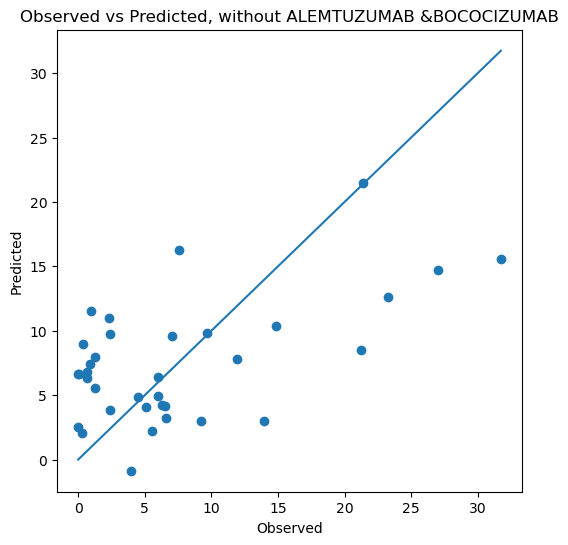

In [34]:
# Predict values based on the model 15
almost_all_predictors_andADA['predicted_ADA'] = model_35AB.predict(almost_all_predictors_andADA)

plt.figure(figsize=(6,6))
plt.scatter(almost_all_predictors_andADA['ADA_percentage'], almost_all_predictors_andADA['predicted_ADA'])

# ideal line (perfect fit)
plt.plot([almost_all_predictors_andADA['ADA_percentage'].min(), almost_all_predictors_andADA['ADA_percentage'].max()],
         [almost_all_predictors_andADA['ADA_percentage'].min(), almost_all_predictors_andADA['ADA_percentage'].max()])

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted, without ALEMTUZUMAB &BOCOCIZUMAB")
plt.show()

# Predict nanobodies

In [35]:
# load csv with columns for nanobodies
all_predictors_NB = pd.read_csv("../Nanobodies/all_predictors_NB.csv")

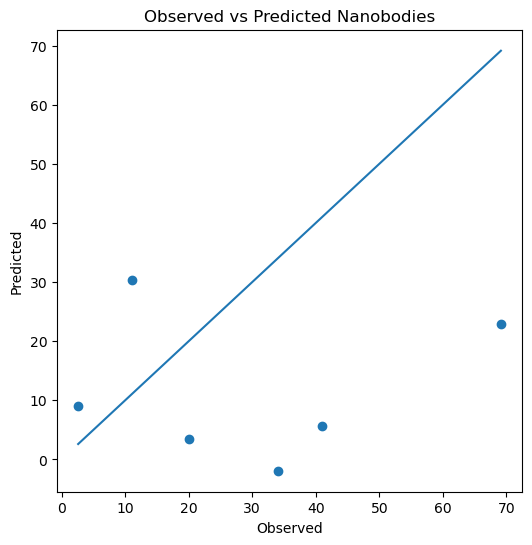

In [36]:
all_predictors_NB['predicted_ADA'] = model14.predict(all_predictors_NB)

plt.figure(figsize=(6,6))
plt.scatter(all_predictors_NB['ADA_percentage'], all_predictors_NB['predicted_ADA'])

# ideal line (perfect fit)
plt.plot([all_predictors_NB['ADA_percentage'].min(), all_predictors_NB['ADA_percentage'].max()],
         [all_predictors_NB['ADA_percentage'].min(), all_predictors_NB['ADA_percentage'].max()])

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted Nanobodies")
plt.show()

In [37]:
from sklearn.metrics import r2_score

r2 = r2_score(all_predictors_NB['ADA_percentage'],
              all_predictors_NB['predicted_ADA'])

r2

-0.8692352723073871

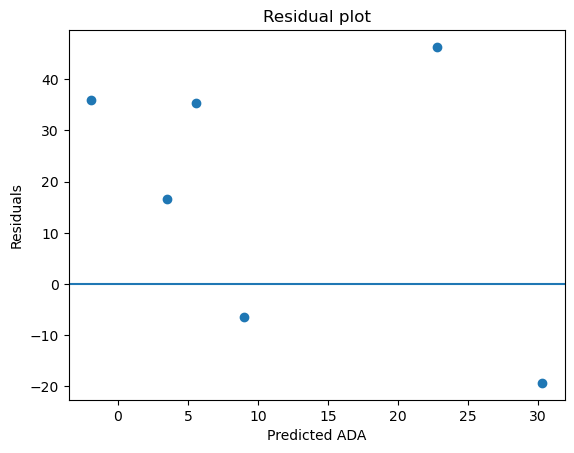

In [38]:
all_predictors_NB['residuals'] = (
    all_predictors_NB['ADA_percentage'] - all_predictors_NB['predicted_ADA']
)
plt.scatter(all_predictors_NB['predicted_ADA'],
            all_predictors_NB['residuals'])
plt.axhline(0)
plt.xlabel("Predicted ADA")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()

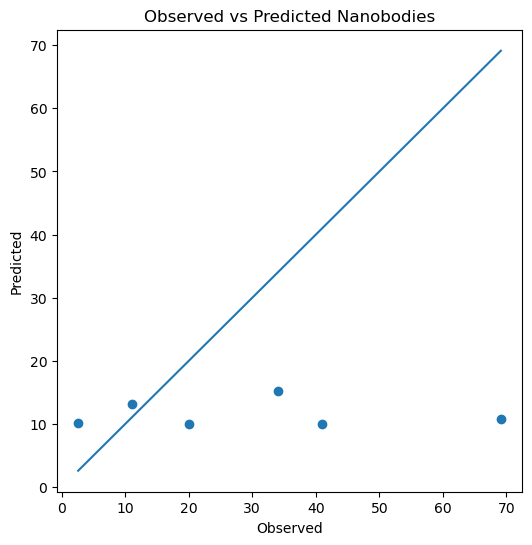

In [39]:
# Do the same prediction with model 8 (only has one predictor: netMHC_pep12_percentile)
all_predictors_NB['predicted_ADA'] = model8.predict(all_predictors_NB)

plt.figure(figsize=(6,6))
plt.scatter(all_predictors_NB['ADA_percentage'], all_predictors_NB['predicted_ADA'])

# ideal line (perfect fit)
plt.plot([all_predictors_NB['ADA_percentage'].min(), all_predictors_NB['ADA_percentage'].max()],
         [all_predictors_NB['ADA_percentage'].min(), all_predictors_NB['ADA_percentage'].max()])

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted Nanobodies")
plt.show()

In [40]:
r2 = r2_score(all_predictors_NB['ADA_percentage'],
              all_predictors_NB['predicted_ADA'])

r2

-0.6937206290281768

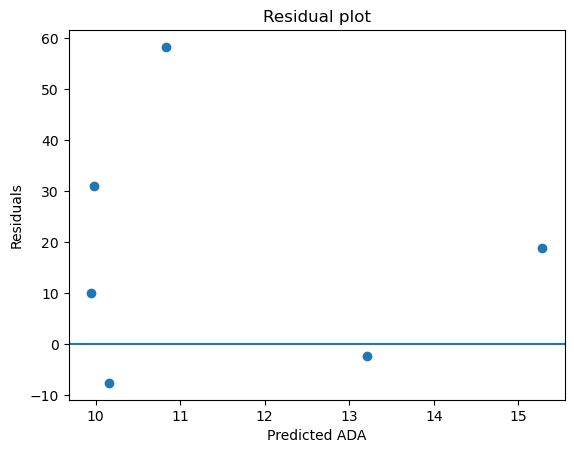

In [41]:
all_predictors_NB['residuals'] = (
    all_predictors_NB['ADA_percentage'] - all_predictors_NB['predicted_ADA']
)
plt.scatter(all_predictors_NB['predicted_ADA'],
            all_predictors_NB['residuals'])
plt.axhline(0)
plt.xlabel("Predicted ADA")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()